In [2]:
import pandas as pd
import numpy as np

import os
import tensorflow as tf
from tensorflow import keras
from keras import layers

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
import sys

# Check environment
print("Python executable:", sys.executable)
print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())

# GPU setup
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU enabled: {gpus}")
    except RuntimeError as e:
        print(f"✗ GPU setup error: {e}")
else:
    print("✗ No GPU detected - running on CPU")

# Test GPU is actually working
print("GPU available for TensorFlow:", tf.test.is_gpu_available())


Python executable: c:\Users\Chohb\AppData\Local\Programs\Python\Python310\python.exe
TensorFlow version: 2.13.1
Built with CUDA: False
✗ No GPU detected - running on CPU
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU available for TensorFlow: False


### Read images

In [2]:
batch_size = 32
img_h, img_w = 256, 256

#       Full DataFrames (For EDA)

monet_df = tf.keras.utils.image_dataset_from_directory(
    "monet_jpg",
    labels=None,
    image_size=(img_h, img_w),
    batch_size=batch_size
)

real_df = tf.keras.utils.image_dataset_from_directory(
    "photo_jpg",
    labels=None,
    image_size=(img_h, img_w),
    batch_size=batch_size
)

#       Split Data (For Modeling)

monet_train = tf.keras.utils.image_dataset_from_directory(
    "monet_jpg",
    labels=None,
    image_size=(img_h, img_w),
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed = 17
)

monet_test = tf.keras.utils.image_dataset_from_directory(
    "monet_jpg",
    labels=None,
    image_size=(img_h, img_w),
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed = 17
)

real_train = tf.keras.utils.image_dataset_from_directory(
    "photo_jpg",
    labels=None,
    image_size=(img_h, img_w),
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed = 17
)

real_test = tf.keras.utils.image_dataset_from_directory(
    "photo_jpg",
    labels=None,
    image_size=(img_h, img_w),
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed = 17
)



Found 300 files belonging to 1 classes.
Found 7038 files belonging to 1 classes.
Found 300 files belonging to 1 classes.
Using 240 files for training.
Found 300 files belonging to 1 classes.
Using 60 files for validation.
Found 7038 files belonging to 1 classes.
Using 5631 files for training.
Found 7038 files belonging to 1 classes.
Using 1407 files for validation.


### Inspect size

In [3]:
num_images = 0
for batch in monet_df:
    num_images += batch.shape[0]
print(f"monet_df size: {num_images}")

num_images = 0
for batch in real_df:
    num_images += batch.shape[0]
print(f"real_df size: {num_images}")

monet_df size: 300
real_df size: 7038


### Inspect Images

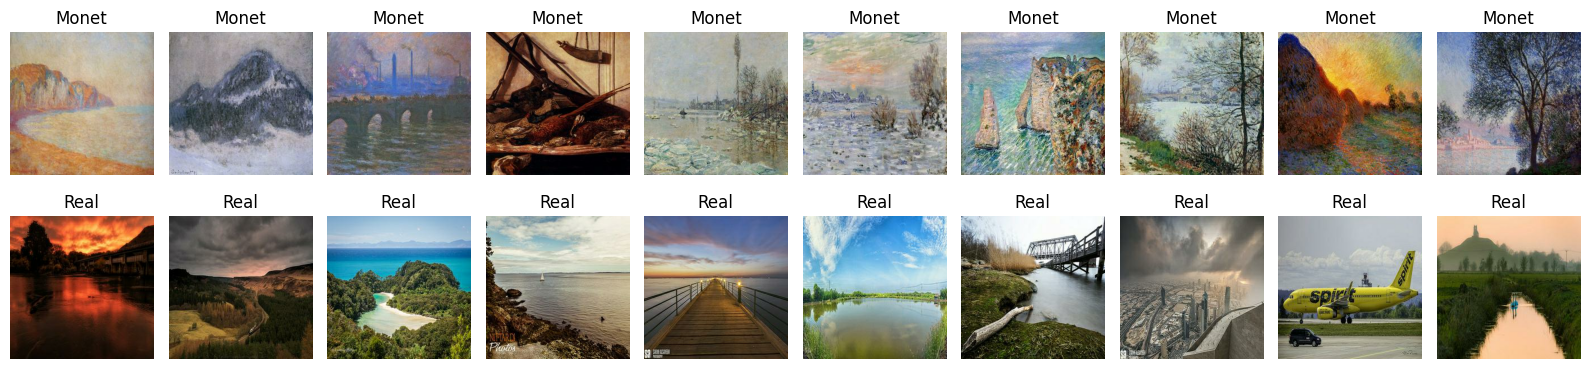

In [4]:
def display_img(monet_df,real_df,num_samples = 10):
    fig, axes = plt.subplots(2, num_samples, figsize=(16, 4))

    # Pull 1 batch from each df (32 images)
    monet_batch = next(iter(monet_df.take(1)))
    real_batch = next(iter(real_df.take(1)))

    for i in range(num_samples):
        #   Monet samples
        img = monet_batch[i].numpy()
        #   Convert pixel vals to [0,1]
        if img.max() > 1:
            img = img / 255.0
        elif img.min() < 0:
            img = (img + 1) / 2

        axes[0, i].imshow(img)
        axes[0, i].set_title('Monet')
        axes[0, i].axis('off')

         # Real samples  
        img = real_batch[i].numpy()
        #   Convert pixel vals to [0,1]
        if img.max() > 1:
            img = img / 255.0
        elif img.min() < 0:
            img = (img + 1) / 2

        axes[1, i].imshow(img)
        axes[1, i].set_title('Real')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

display_img(monet_df,real_df)

### Color Distribution Analysis
We will inspect how the 2 datasets differ color-wise.

Mean (Monet): 130.87359619140625, Std: 57.9273567199707
Mean (Real): 95.77972412109375, Std: 68.17515563964844
Mean Diff: 35.0938720703125


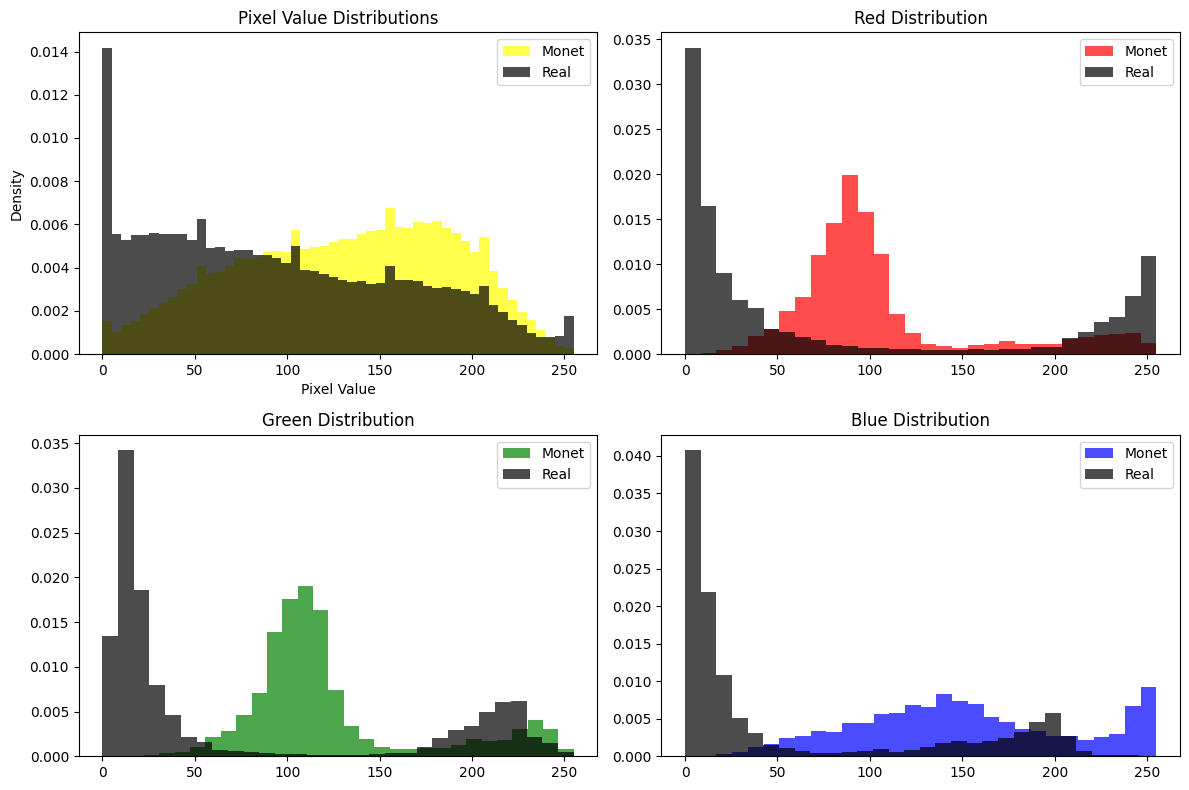

In [5]:
def cda(monet_df, real_df):
    monet_pixels = []
    real_pixels = []
    
    # Sample 3 batches
    for batch in monet_df.take(3):
        monet_pixels.extend(batch.numpy().flatten())
    
    for batch in real_df.take(3):
        real_pixels.extend(batch.numpy().flatten())
    
    monet_pixels = np.array(monet_pixels)
    real_pixels = np.array(real_pixels)
    
    # Mean/STD Analysis
    print(f"Mean (Monet): {monet_pixels.mean()}, Std: {monet_pixels.std()}")
    print(f"Mean (Real): {real_pixels.mean()}, Std: {real_pixels.std()}")
    print(f"Mean Diff: {abs(monet_pixels.mean() - real_pixels.mean())}")
    
    # Pixel distribution
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
    
    ax1.hist(monet_pixels[::100], bins=50, alpha=0.7, label='Monet', color='yellow', density=True)
    ax1.hist(real_pixels[::100], bins=50, alpha=0.7, label='Real', color='black', density=True)
    ax1.set_title('Pixel Value Distributions')
    ax1.set_xlabel('Pixel Value')
    ax1.set_ylabel('Density')
    ax1.legend()
    
    # Pull 1 batch for color comparisons
    monet_sample = next(iter(monet_df.take(1)))
    real_sample = next(iter(real_df.take(1)))
    
    # Red
    ax2.hist(monet_sample[0].numpy()[:,:,0].flatten(), bins=30, alpha=0.7, label='Monet', color='red', density=True)
    ax2.hist(real_sample[0].numpy()[:,:,0].flatten(), bins=30, alpha=0.7, label='Real', color='black', density=True)
    ax2.set_title('Red Distribution')
    ax2.legend()
    
    # Green
    ax3.hist(monet_sample[0].numpy()[:,:,1].flatten(), bins=30, alpha=0.7, label='Monet', color='green', density=True)
    ax3.hist(real_sample[0].numpy()[:,:,1].flatten(), bins=30, alpha=0.7, label='Real', color='black', density=True)
    ax3.set_title('Green Distribution')
    ax3.legend()
    
    # Blue
    ax4.hist(monet_sample[0].numpy()[:,:,2].flatten(), bins=30, alpha=0.7, label='Monet', color='blue', density=True)
    ax4.hist(real_sample[0].numpy()[:,:,2].flatten(), bins=30, alpha=0.7, label='Real', color='black', density=True)
    ax4.set_title('Blue Distribution')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()

# Run the actual analysis
cda(monet_df, real_df)


On average, Monet works seem to use brighter colors than the real images, (~20 average pixel difference). \
Furthermore, Monet has more diversity in his coloring than the real images, (~10 higher distribution of colors). \
Conclusion: Monet uses more bright, vibrant, diverse colors than we see in real images. \

### How will this help us?
Maybe have our loss function focus on color and vibrancy?

# Modeling
We will use CycleGAN to perform style transfer on the real images to create beautiful Monet's. \
Originally, I was expecting to use DCGAN or standard GAN architecture, however this would be the approach if we were generating images from noise. \
For this project, we are turning real photos into paintings (style transfer).


### CycleGAN
This approach uses "cycle consistency loss". Because of this, we need 2 generators; Real -> Monet & Monet -> Real.

#### Generator

In [6]:
#   Building Blocks (From CycleGAN doc)
class ReflectionPadding2D(layers.Layer):
    def __init__(self, padding=1, **kwargs):
        super().__init__(**kwargs)
        self.padding = padding
    
    def call(self, x):
        return tf.pad(x, [[0,0], [self.padding, self.padding], [self.padding, self.padding], [0,0]], "REFLECT")
    
class InstanceNormalization(layers.Layer):
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon
    
    def build(self, input_shape):
        self.scale = self.add_weight(shape=(input_shape[-1],), initializer='ones',trainable=True)
        self.offset = self.add_weight(shape=(input_shape[-1],), initializer='zeros', trainable=True)
    
    def call(self, x):
        mean,variance = tf.nn.moments(x, axes=[1,2], keepdims=True)
        inv = tf.math.rsqrt(variance + self.epsilon)
        normalized = (x - mean) * inv
        
        return self.scale * normalized + self.offset

In [7]:
def conv_block(x, filters, kernel_size=3, strides=1, padding='same', use_bias=False, use_norm=True, activation='relu'):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding=padding, use_bias=use_bias)(x)

    #   Instance norm instead of batch norm. For style transfer, we want to preserve the entire image, not average per batch.
    if use_norm:
        x = InstanceNormalization()(x)
    
    if activation == 'relu':
        x = layers.ReLU()(x)
    elif activation == 'leaky':
        x = layers.LeakyReLU(0.2)(x)
    
    return x

#   Residual_block is vital to cyclegan bc it maintains the information of the base image. Without it, we would be building a Monet from scratch.
def residual_block(x, filters):
    skip = x
    x = conv_block(x, filters, kernel_size=3, strides=1)
    x = conv_block(x, filters, kernel_size=3, strides=1, activation=None)
    x = layers.Add()([x, skip])
    
    return x

def build_generator(input_shape=(256, 256, 3), num_filters=64):
    inputs = keras.Input(shape=input_shape)

    x = ReflectionPadding2D(3)(inputs)
    x = conv_block(x, num_filters, kernel_size=7, strides=1, padding='valid')

    x = conv_block(x, num_filters * 2, kernel_size=3, strides=2)

    x = conv_block(x, num_filters * 4, kernel_size=3, strides=2)

    #   6 Residual Blocks
    for _ in range(6):
        x = residual_block(x, num_filters * 4)
    
    x = layers.Conv2DTranspose(num_filters * 2, 3, strides=2, padding='same', use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(num_filters, 3, strides=2, padding='same', use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)

    x = ReflectionPadding2D(3)(x)
    outputs = layers.Conv2D(3, 7, strides=1, padding='valid', activation='tanh')(x)

    return keras.Model(inputs, outputs, name='generator')

In [8]:
#   Discriminator
def build_discriminator(input_shape=(256,256,3)):
    inputs = keras.Input(shape=input_shape)

    #   64
    x = layers.Conv2D(64, 4, strides=2, padding='same')(inputs)
    x = layers.LeakyReLU(0.2)(x)

    #   128
    x = layers.Conv2D(128, 4, strides=2, padding='same', use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    #   256
    x = layers.Conv2D(256, 4, strides=2, padding='same', use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    #   512
    x = layers.Conv2D(512, 4, strides=1, padding='same', use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    outputs = layers.Conv2D(1, 4, strides=1, padding='same')(x)

    return keras.Model(inputs, outputs, name="discriminator")

In [9]:
#   Define losses (built in)
adv_loss_fn = keras.losses.MeanSquaredError()
cycle_loss_fn = keras.losses.MeanAbsoluteError()
identity_loss_fn = keras.losses.MeanAbsoluteError()

In [10]:
class CycleGan(keras.Model):
    def __init__(self, generator_G, generator_F, discriminator_X, discriminator_Y, lambda_cycle=10.0, lambda_identity=0.5,):
        super().__init__()
        self.gen_G = generator_G
        self.gen_F = generator_F
        self.disc_X = discriminator_X
        self.disc_Y = discriminator_Y
        self.lambda_cycle = lambda_cycle
        self.lambda_identity = lambda_identity
    
    def compile(self, gen_g_optimizer, gen_f_optimizer, disc_x_optimizer, disc_y_optimizer):
        super().compile()
        self.gen_g_optimizer = gen_g_optimizer
        self.gen_f_optimizer = gen_f_optimizer
        self.disc_x_optimizer = disc_x_optimizer
        self.disc_y_optimizer = disc_y_optimizer

        self.gen_g_loss_metric = keras.metrics.Mean(name="gen_g_loss")
        self.gen_f_loss_metric = keras.metrics.Mean(name="gen_f_loss")
        self.disc_x_loss_metric = keras.metrics.Mean(name="disc_x_loss")
        self.disc_y_loss_metric = keras.metrics.Mean(name="disc_y_loss")
    
    @property
    def metrics(self):
        return [
            self.gen_g_loss_metric,
            self.gen_f_loss_metric,
            self.disc_x_loss_metric,
            self.disc_y_loss_metric,
        ]
    
    def train_step(self, batch_data):
        real_x, real_y = batch_data #x = photos, y = monets

        with tf.GradientTape(persistent=True) as tape:
            #   Forward cycle
            fake_y = self.gen_G(real_x, training=True)
            cycled_x = self.gen_F(fake_y, training=True)

            #   Backward cycle
            fake_x = self.gen_F(real_y, training=True)
            cycled_y = self.gen_G(fake_x, training=True)

            #   ID mapping
            same_x = self.gen_F(real_x, training=True)
            same_y = self.gen_G(real_y, training=True)

            #   Discrim Outputs
            disc_real_x = self.disc_X(real_x, training=True)
            disc_fake_x = self.disc_X(fake_x, training=True)
            disc_real_y = self.disc_Y(real_y, training=True)
            disc_fake_y = self.disc_Y(fake_y, training=True)

            #   Gen adversarial loss
            gen_g_loss = adv_loss_fn(tf.ones_like(disc_fake_y), disc_fake_y)
            gen_f_loss = adv_loss_fn(tf.ones_like(disc_fake_x), disc_fake_x)

            #   Cycle consistency loss
            cycle_loss_g = cycle_loss_fn(real_y, cycled_y) * self.lambda_cycle
            cycle_loss_f = cycle_loss_fn(real_x, cycled_x) * self.lambda_cycle

            #   ID Loss
            identity_loss_g = identity_loss_fn(real_y, same_y) * self.lambda_cycle * self.lambda_identity
            identity_loss_f = identity_loss_fn(real_x, same_x) * self.lambda_cycle * self.lambda_identity

            #   Total Gen Loss
            total_gen_g_loss = gen_g_loss + cycle_loss_g + identity_loss_g
            total_gen_f_loss = gen_f_loss + cycle_loss_f + identity_loss_f

            #   Discriminator Losses
            disc_x_loss = (adv_loss_fn(tf.ones_like(disc_real_x), disc_real_x) + adv_loss_fn(tf.zeros_like(disc_fake_x), disc_fake_x)) * 0.5
            disc_y_loss = (adv_loss_fn(tf.ones_like(disc_real_y), disc_real_y) + adv_loss_fn(tf.zeros_like(disc_fake_y), disc_fake_y)) * 0.5

        #   Apply Gradients
        gen_g_gradients = tape.gradient(total_gen_g_loss, self.gen_G.trainable_variables)
        gen_f_gradients = tape.gradient(total_gen_f_loss, self.gen_F.trainable_variables)
        disc_x_gradients = tape.gradient(disc_x_loss, self.disc_X.trainable_variables)
        disc_y_gradients = tape.gradient(disc_y_loss, self.disc_Y.trainable_variables)

        self.gen_g_optimizer.apply_gradients(zip(gen_g_gradients, self.gen_G.trainable_variables))
        self.gen_f_optimizer.apply_gradients(zip(gen_f_gradients, self.gen_F.trainable_variables))
        self.disc_x_optimizer.apply_gradients(zip(disc_x_gradients, self.disc_X.trainable_variables))
        self.disc_y_optimizer.apply_gradients(zip(disc_y_gradients, self.disc_Y.trainable_variables))

        # Update metrics
        self.gen_g_loss_metric.update_state(total_gen_g_loss)
        self.gen_f_loss_metric.update_state(total_gen_f_loss)
        self.disc_x_loss_metric.update_state(disc_x_loss)
        self.disc_y_loss_metric.update_state(disc_y_loss)

        return {
            "gen_g_loss": self.gen_g_loss_metric.result(),
            "gen_f_loss": self.gen_f_loss_metric.result(),
            "disc_x_loss": self.disc_x_loss_metric.result(),
            "disc_y_loss": self.disc_y_loss_metric.result(),
        }

In [11]:
gen_g = build_generator()  # Photo → Monet
gen_f = build_generator()  # Monet → Photo
disc_x = build_discriminator()  # Photo disc
disc_y = build_discriminator()  # Monet disc

cycle_gan_model = CycleGan(gen_g, gen_f, disc_x, disc_y)

# Compile
cycle_gan_model.compile(
    gen_g_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    gen_f_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    disc_x_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    disc_y_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
)

# Combine training df's
train_dataset = tf.data.Dataset.zip((real_train, monet_train))

# Train
cycle_gan_model.fit(train_dataset, epochs=4)

Epoch 1/4


# Evaluation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_losses(losses):
    g_losses = losses['g_losses']
    d_a_losses = losses['d_a_losses']
    d_b_losses = losses['d_b_losses']
    cycle_losses = losses['cycle_losses']
    identity_losses = losses['identity_losses']
    print(d_a_losses)
    print(d_b_losses)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(g_losses, label='Generator Total Loss')
    plt.plot(d_a_losses, label='Discriminator A Loss')
    plt.plot(d_b_losses, label='Discriminator B Loss')
    plt.title('Adversarial Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(cycle_losses, label='Cycle Consistency Loss')
    plt.plot(identity_losses, label='Identity Loss')
    plt.title('Regularization Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


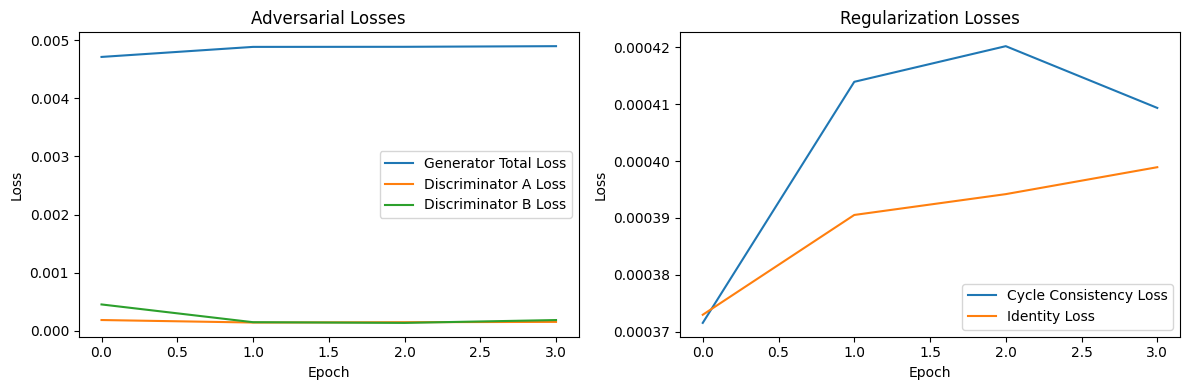

In [10]:
losses = np.load("cycleGAN_losses.npz")
plot_losses(losses)

Validation MiFID Score: 261.83
#   Enterpretation
### Adversarial Losses
- Generator Total Losses: Sum of all generator loss (adversarial + cycle + identity)
    - Lower the loss, better the generator is
- Descriminator A (A = real domain) loss: Distinguishes real from generated images
    - Higher the loss, better the descriminator
- Descriminator B (B = Monet domain) loss: ''
    - ''

### Regularization Losses
- Cycle Consistency Loss: How well the model reconstructs original image after a cycle translation (A→B→A or B→A→B)
    - Lower the loss, better the reconstruction
- Identity Loss: How much the generators change images already in the target domain
    - Lower the loss, better the model preserves content when it should.

### I2 Changes
- Image Augmentation
- Increase batch size
- Logic error in training loop fixed. Losses were being reset every batch!

Validation MiFID Score: 202.09

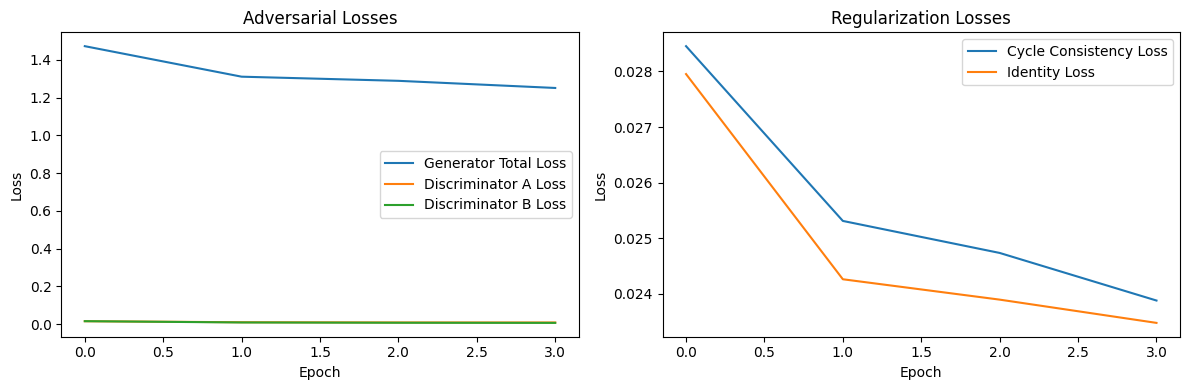

In [3]:
losses = np.load("cycleGAN_losses2.npz")
plot_losses(losses)

Now, let's try running this on 100 epochs.

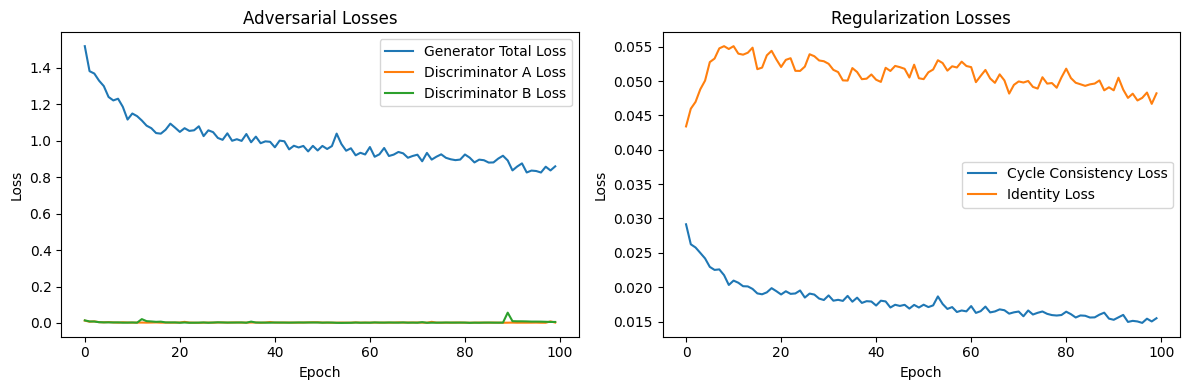

In [5]:
losses = np.load("cycleGAN_losses3.npz")
plot_losses(losses)

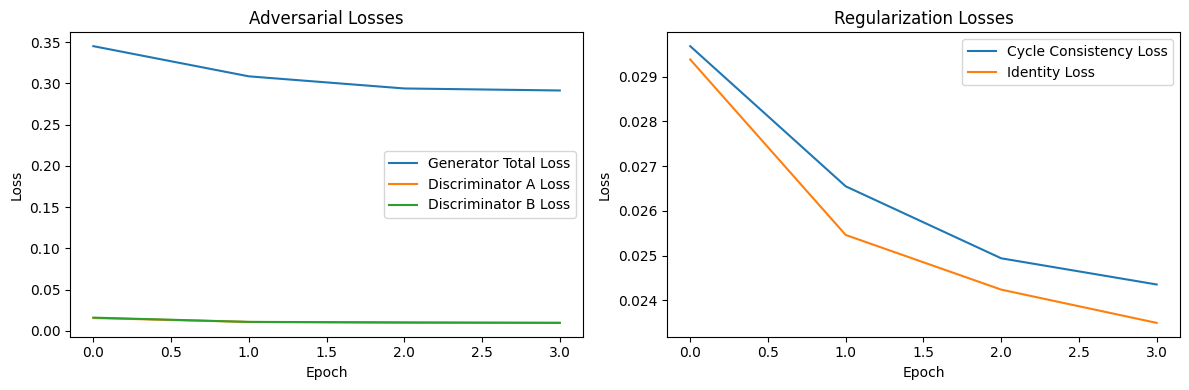

In [3]:
losses = np.load("cycleGAN_losses4.npz")
plot_losses(losses)

## Issue found
In the training loop, we were iterating through a zip() of both monet's and photos. This uses the min() of both datasets, meaning it cuts the 7000 photo dataset to match the monet dataset of 300. \
To fix, we iterate through the 7000 photos and recycle 300 monet paintings once we're out.

### Computation cost becomes an issue
Now, the issue is computation. Each epoch is taking too long for my GPU.
- mixed precision
- Label smoothing

[0.10973365 0.10339434 0.10284674 0.1003474 ]
[0.11129647 0.10382047 0.09902476 0.08360105]


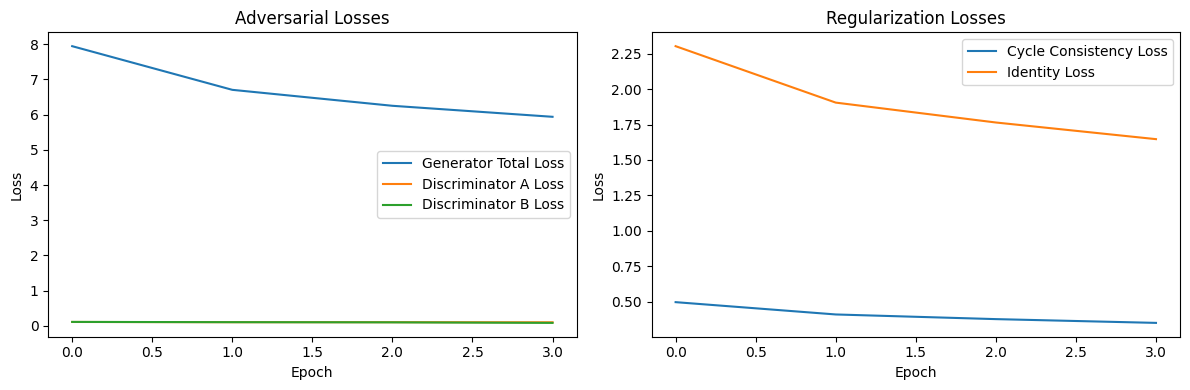

In [10]:
losses = np.load("cycleGAN_losses5.npz")
plot_losses(losses)

Slight improvement! MiFID dropped significantly to 182, although still not acceptable. \
A higher epoch run may yield better results. \
However I'm concerned about the discriminator losses being so low. It seems as though our discriminators are overfitting or are too strong for the generators.

### Next
To try and nerf the discriminators further, let's skip it's updates.

[0.68410608 0.67945052 0.68013514 0.67759438 0.6757584  0.67608158
 0.67762903 0.67616821 0.67648032 0.6757082 ]
[0.68203751 0.68026082 0.68009576 0.67842104 0.67596632 0.67802605
 0.67948503 0.68059851 0.67932921 0.67889394]


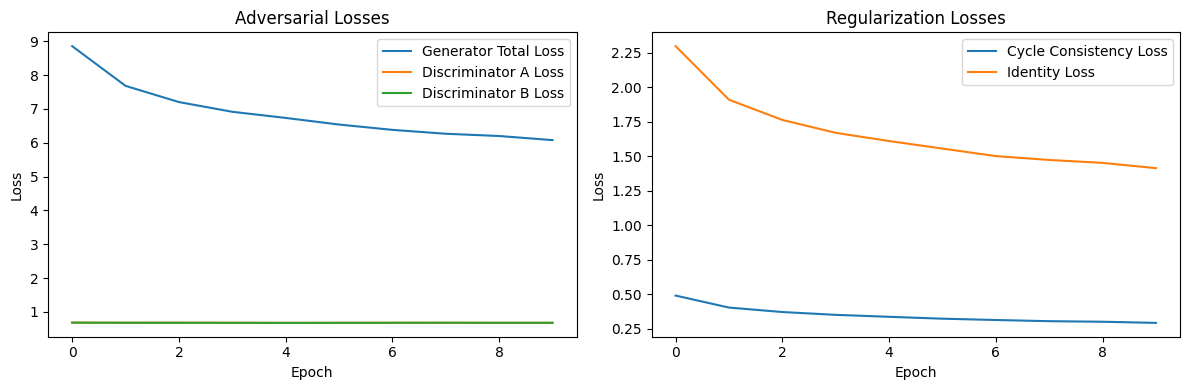

In [2]:
losses = np.load("cycleGAN_losses6.npz")
plot_losses(losses)

Epoch 13/100
- Reverting back to MSELOSS, from BCEWithLogitLoss.
- Removing discriminator update skip (from every 10 steps).
- Reducing discriminator noise
- Narrower label smoothing
- Reducing identity_lambda to almost 0 (removing identity loss)
- 

[0.15062871 0.1359204  0.13078254 0.12240898 0.10932303 0.10114969
 0.11042681 0.11815495 0.11881445 0.11847185 0.11859897]
[0.14900103 0.12628849 0.09749127 0.07462799 0.10130068 0.11098063
 0.11502371 0.11475277 0.11274658 0.11458472 0.11379974]


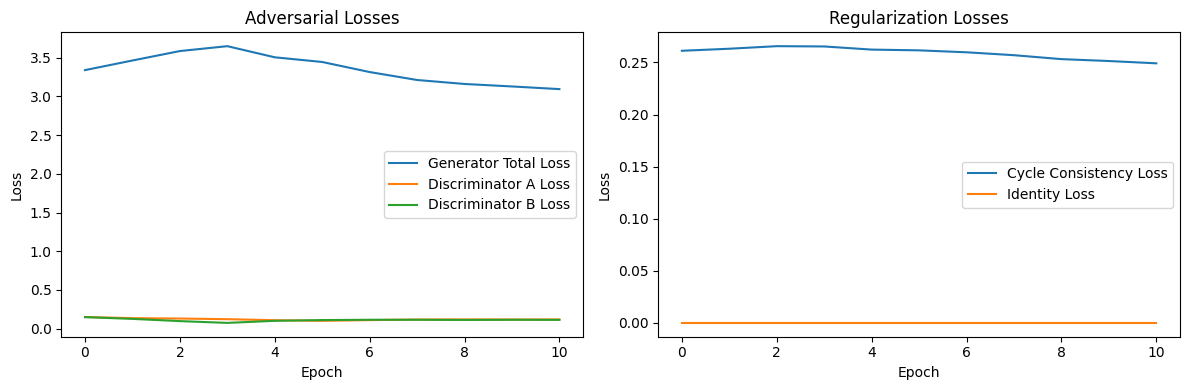

In [3]:
losses = np.load("cycleGAN_losses7.npz")
plot_losses(losses)